In [10]:
from neuromaps import NeuroMapFixed

model = NeuroMapFixed.load("checkpoints/model.ckpt")

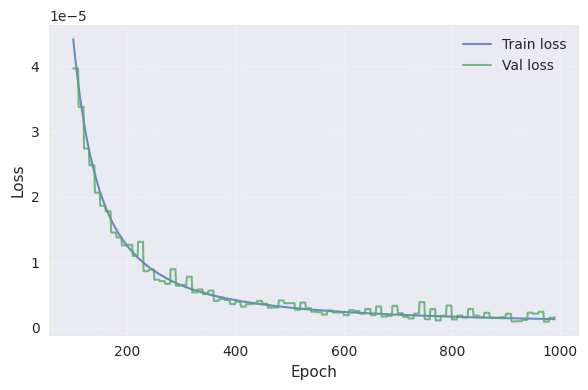

In [11]:
import matplotlib.pyplot as plt
import numpy as np

hist_f = model.training_history

plt.style.use("seaborn-v0_8")
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

start = 100
train_loss_full = hist_f["train_loss"]
val_loss_full = hist_f.get("val_loss", None)

if val_loss_full is not None:
    min_len = min(len(train_loss_full), len(val_loss_full)) - start
    epochs = np.arange(start, start + min_len)
    train_loss = train_loss_full[start:start + min_len]
    val_loss = val_loss_full[start:start + min_len]
else:
    epochs = np.arange(start, len(train_loss_full))
    train_loss = train_loss_full[start:]
    val_loss = None

ax.plot(epochs, train_loss, lw=1.5, alpha=.8, label="Train loss")
if val_loss is not None:
    ax.plot(epochs, val_loss, lw=1.5, alpha=.8, label="Val loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, ls="--", alpha=.3)
if val_loss is not None:
    ax.legend()
plt.tight_layout()
plt.show()

Симуляция: 100%|███████████████████████████████████████████| 10000/10000 [00:01<00:00, 9385.55шаг/s]


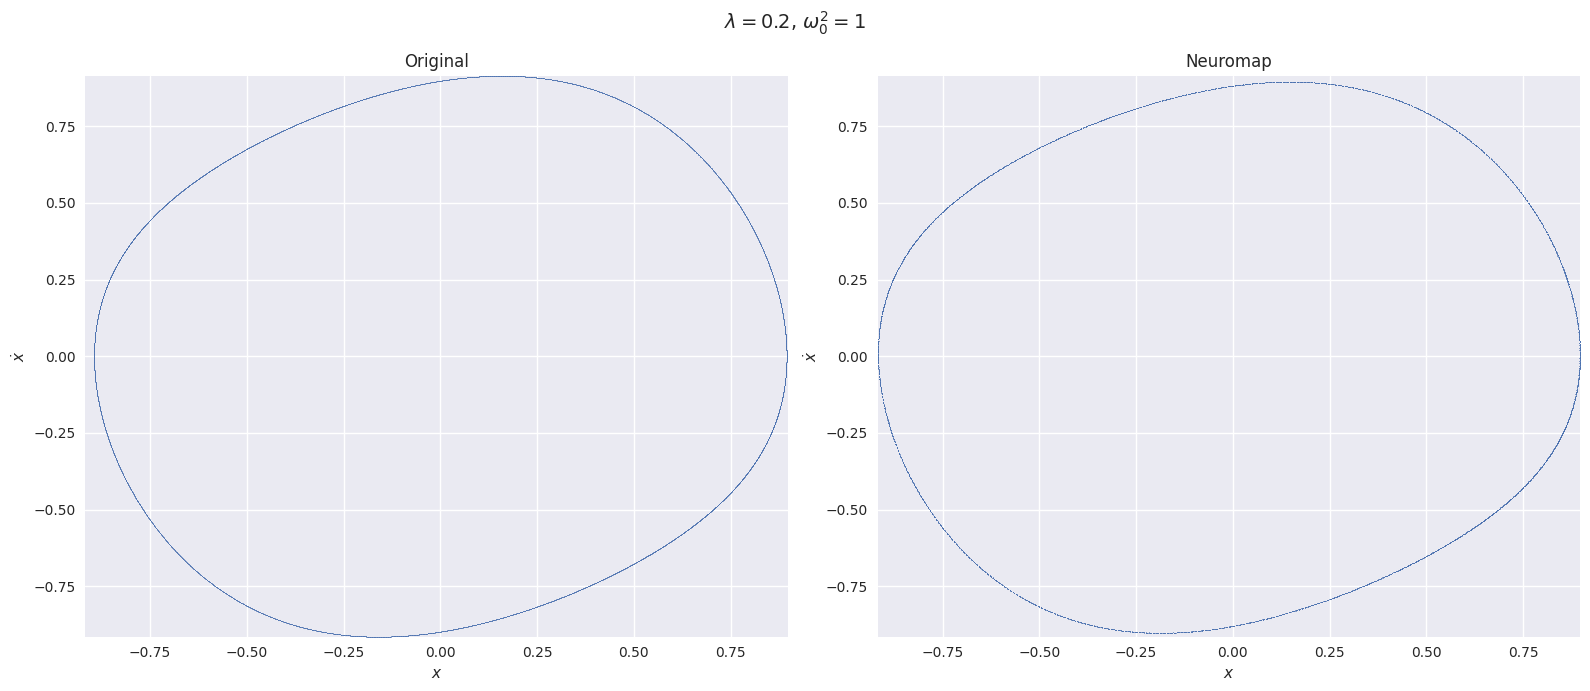

In [12]:
from neuromaps import NeuroMapFixed
from utils import plot_trajectory
from systems.van_der_pol_rk4 import van_der_pol_rk4
from utils import get_attractor_trajectory, plot_trajectory
from utils import plot_compare

u0 = [0.5, 0.7]
p = [0.2, 1]

nm_traj = model.simulate(u0=u0, p=p, n_steps=10000)[2000:]
ode_traj = get_attractor_trajectory(van_der_pol_rk4, u0, p, 0.01, 50, 50, lambda x: x[1])

caption = r'$\lambda=$' + str(p[0]) + r', $\omega_0^2=$' + str(p[1])
plot_compare(ode_traj, nm_traj, caption=caption)

Симуляция: 100%|███████████████████████████████████████████| 10000/10000 [00:01<00:00, 9916.16шаг/s]


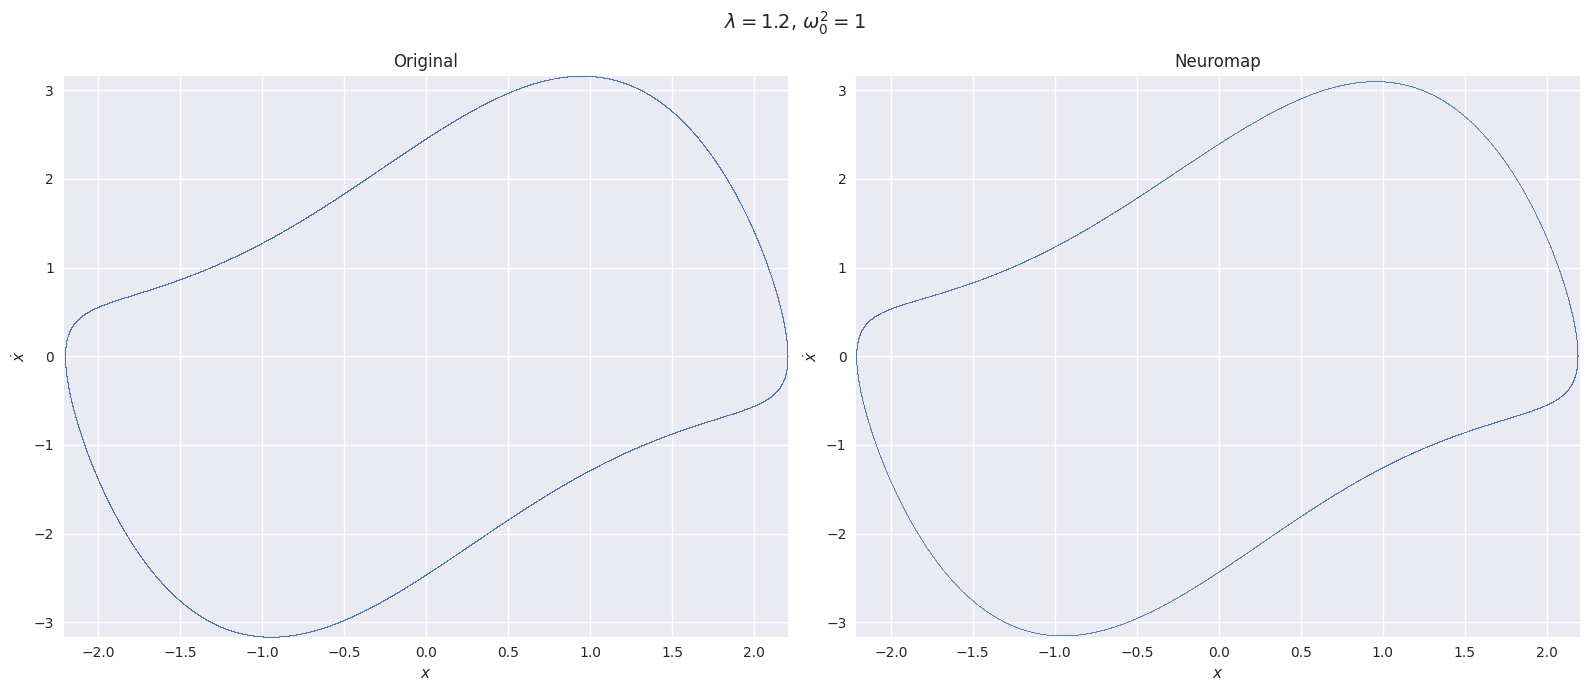

In [13]:
u0 = [0.5, 0.7]
p = [1.2, 1]

nm_traj = model.simulate(u0=u0, p=p, n_steps=10000)[2000:]
ode_traj = get_attractor_trajectory(van_der_pol_rk4, u0, p, 0.01, 50, 50, lambda x: x[1])

caption = r'$\lambda=$' + str(p[0]) + r', $\omega_0^2=$' + str(p[1])
plot_compare(ode_traj, nm_traj, caption=caption)

Симуляция: 100%|███████████████████████████████████████████| 10000/10000 [00:01<00:00, 9750.45шаг/s]


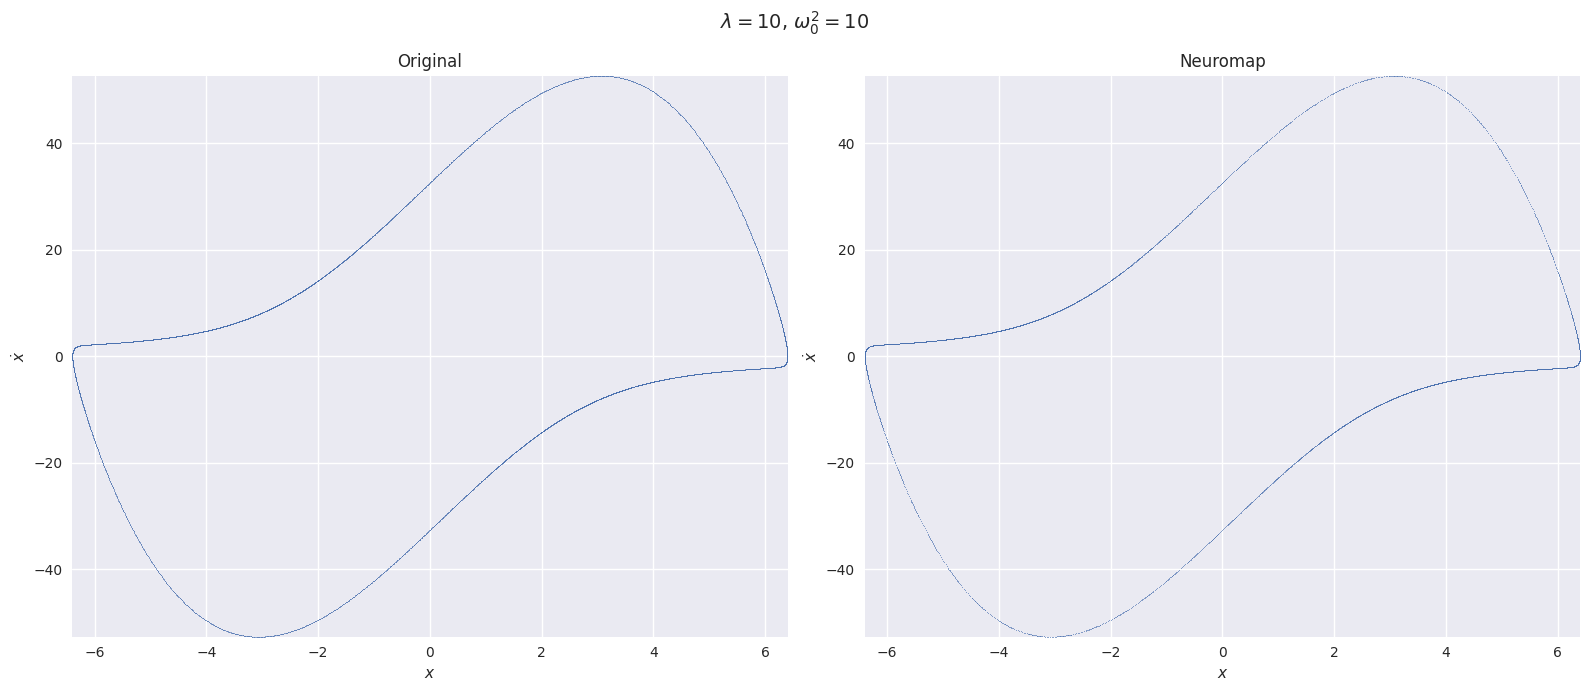

In [15]:
u0 = [0.5, 0.7]
p = [10, 10]

nm_traj = model.simulate(u0=u0, p=p, n_steps=10000)[2000:]
ode_traj = get_attractor_trajectory(van_der_pol_rk4, u0, p, 0.01, 50, 50, lambda x: x[1])

caption = r'$\lambda=$' + str(p[0]) + r', $\omega_0^2=$' + str(p[1])
plot_compare(ode_traj, nm_traj, caption=caption)

Вычисление сетки (по строкам): 100%|██████████| 20/20 [02:08<00:00,  6.40s/it]


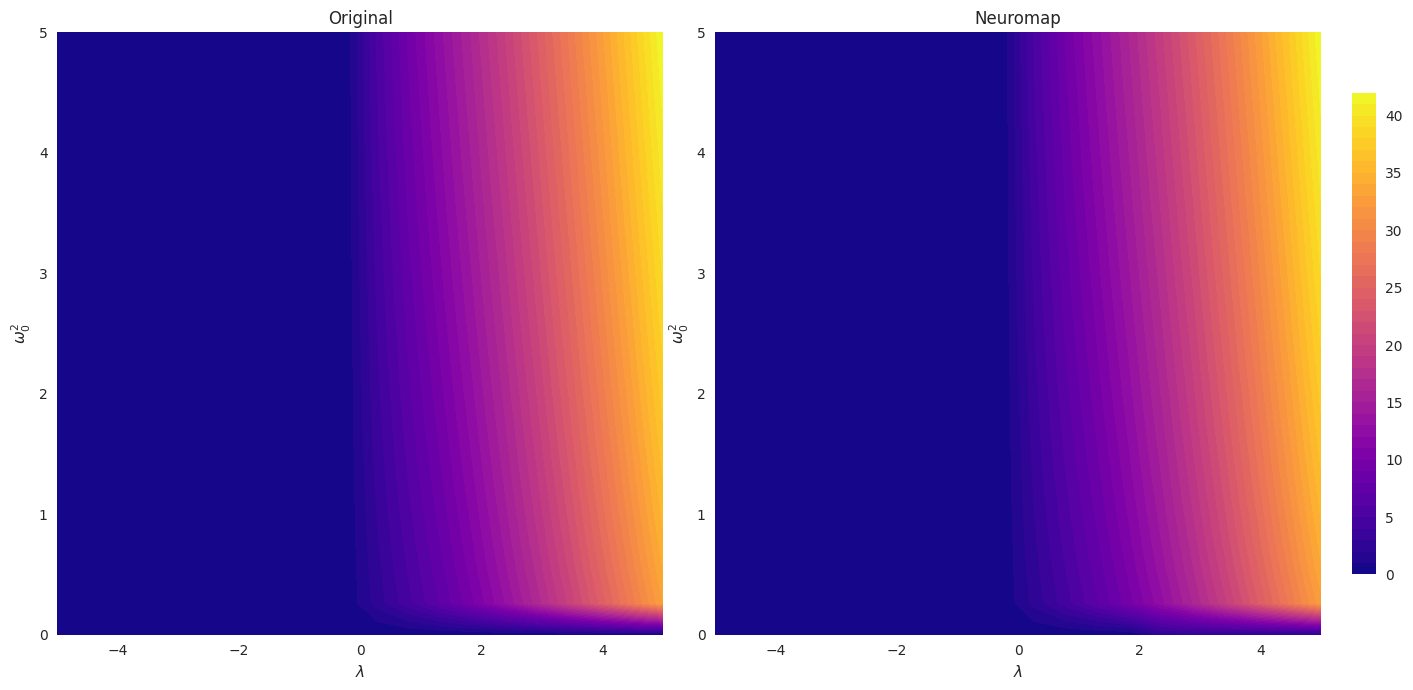

In [16]:
import numpy as np
from utils.trajectories import grid_of_amplitude
from utils.plots import plot_compare_heatmaps
from systems.van_der_pol_rk4 import van_der_pol_rk4

x = np.linspace(-5, 5, 20)
y = np.linspace(0, 5, 20)
u0 = [0.6, 0.7]

Z_nm = grid_of_amplitude(van_der_pol_rk4, u0, [x, y], 0.01, 2000, 8000, model=model)
Z_ode = grid_of_amplitude(van_der_pol_rk4, u0, [x, y], 0.01, 20, 20, lambda x: x[0])
plot_compare_heatmaps(x, y, Z_ode, Z_nm, x_label=r'$\lambda$', y_label=r'$\omega_0^2$')

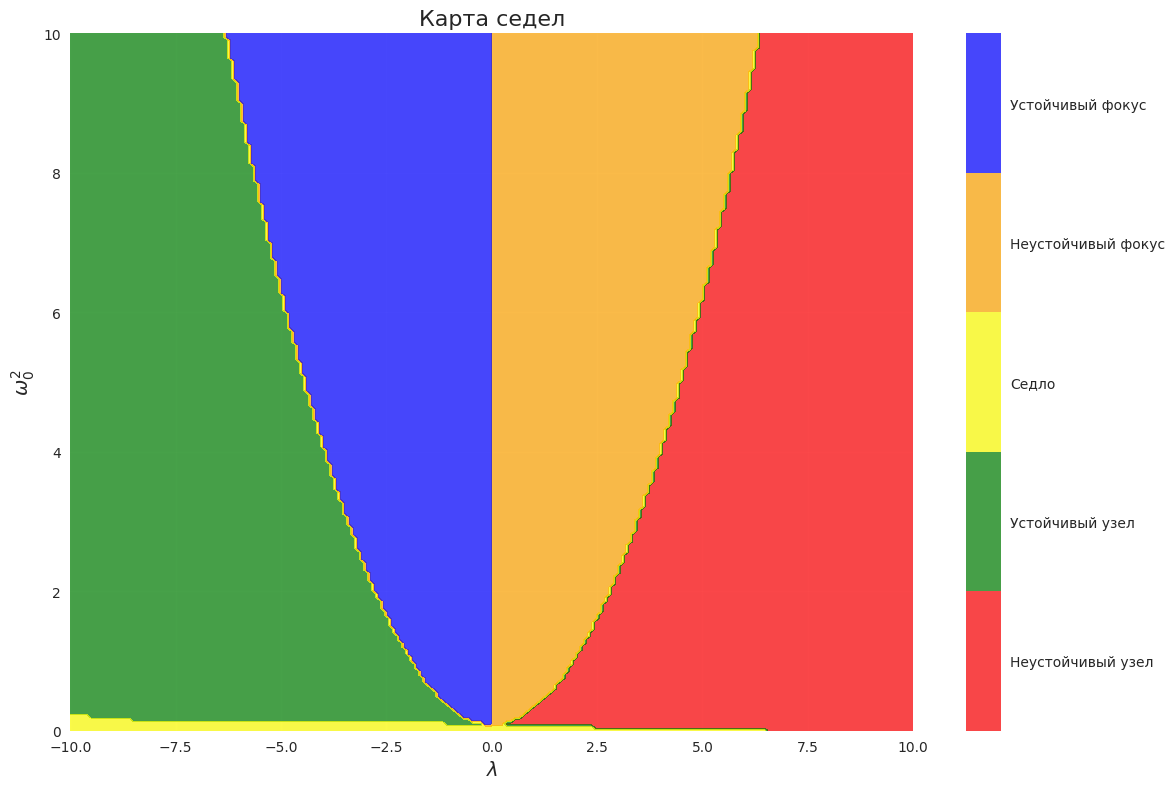

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def classify_multipliers(multipliers):
    mu1, mu2 = multipliers
    
    is_complex = np.iscomplex(mu1) or np.iscomplex(mu2)
    
    if is_complex:
        magnitude = np.abs(mu1)
        if magnitude < 1:
            return 5
        else:
            return 4
    else:
        mu1_real, mu2_real = np.real(mu1), np.real(mu2)
        if abs(mu1_real) < 1 and abs(mu2_real) < 1:
            return 2
        elif abs(mu1_real) > 1 and abs(mu2_real) > 1:
            return 1
        else:
            return 3

def create_equilibrium_map_nn(model, lambda_vals, w0_sq_vals):
    n_lambda = len(lambda_vals)
    n_w0 = len(w0_sq_vals)
    
    equilibrium_type = np.zeros((n_w0, n_lambda))
    
    for i, lambda_val in enumerate(lambda_vals):
        for j, w0_sq_val in enumerate(w0_sq_vals):
            p = np.array([[lambda_val, w0_sq_val]])
            
            try:
                multipliers = model.compute_fixed_point_multipliers([0.0, 0.0], p)
                
                eq_type = classify_multipliers(multipliers)
                equilibrium_type[j, i] = eq_type
                
            except Exception as e:
                print(f"Ошибка в точке ({lambda_val}, {w0_sq_val}): {e}")
                equilibrium_type[j, i] = 0
    
    return equilibrium_type

def plot_equilibrium_map(lambda_vals, w0_sq_vals, equilibrium_type, title="Карта седел"):
    type_labels = {
        1: 'Неустойчивый узел',
        2: 'Устойчивый узел', 
        3: 'Седло',
        4: 'Неустойчивый фокус',
        5: 'Устойчивый фокус'
    }
    
    colors = ['red', 'green', 'yellow', 'orange', 'blue']
    
    plt.figure(figsize=(12, 8))
    contour = plt.contourf(lambda_vals, w0_sq_vals, equilibrium_type, 
                          levels=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], 
                          colors=colors, 
                          alpha=0.7)
    
    cbar = plt.colorbar(contour, ticks=[1, 2, 3, 4, 5])
    cbar.ax.set_yticklabels([type_labels[i] for i in [1, 2, 3, 4, 5]])
    
    plt.xlabel(r'$\lambda$', fontsize=14)
    plt.ylabel(r'$\omega_0^2$', fontsize=14)
    plt.title(title, fontsize=16)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

lambda_vals = np.linspace(-10, 10, 200)
w0_sq_vals = np.linspace(0, 10, 200)

equilibrium_type_nn = create_equilibrium_map_nn(model, lambda_vals, w0_sq_vals)
plot_equilibrium_map(lambda_vals, w0_sq_vals, equilibrium_type_nn)